In [17]:
import pandas as pd
import numpy as np
import matplotlib as mlt
import scipy.stats as ss

In [18]:
PATH = 'EVALMASTER.xlsx'

In [19]:
df = pd.read_excel(PATH)
print(df.head(5))
df.describe()

   Grupo de control  Nivel glucosa basal  Nivel glucosa 60 min
0                 1                   90                   159
1                 1                   82                   151
2                 1                   80                   148
3                 1                   75                   138
4                 1                   74                   141


,Grupo de control,Nivel glucosa basal,Nivel glucosa 60 min
count,65.000000,65.000000,65.000000
mean,1.461538,86.861538,160.292308
std,0.502398,8.462928,14.231043
min,1.000000,65.000000,131.000000
25%,1.000000,80.000000,149.000000
50%,1.000000,88.000000,159.000000
75%,2.000000,93.000000,172.000000
max,2.000000,104.000000,197.000000


# EJERCICO 1
## A. Medidas de centralización

In [20]:
# Agrupar por 'Grupo de control' y calcular medidas de centralización y dispersión para 'Nivel glucosa basal'
grouped = df.groupby('Grupo de control')['Nivel glucosa basal']
stats = grouped.agg(['count','min','max','mean','median'])
# Calcular la(s) moda(s) por grupo (puede haber más de una)
modes = grouped.apply(lambda s: s.mode().tolist())
stats['mode'] = modes
# Dispersion
stats_dispersion = grouped.agg(['std','var'])
iqr = grouped.quantile(0.75) - grouped.quantile(0.25)
stats['std'], stats['var'] = stats_dispersion['std'], stats_dispersion['var']
stats['IQR'] = iqr

sk_by_group = df.groupby('Grupo de control')['Nivel glucosa basal'] \
                .apply(lambda x: ss.skew(x.dropna(), bias=False))

print(stats)

                  count  min  max       mean  median              mode  \
Grupo de control                                                         
1                    35   65  103  84.685714    82.0  [75, 79, 82, 90]   
2                    30   77  104  89.400000    90.0              [88]   

                       std        var   IQR  
Grupo de control                             
1                 8.844312  78.221849  12.0  
2                 7.346592  53.972414   9.5  


A) La media es una claramente respresentativa, en grupo 2 casi perfecta. Las medias y medianas son muy parecidas y el coeficeinte de variacion es ~0, aunque el grupo 1 tiene una variacion ligeramente positiva.

In [21]:
#Cálculo de simetría y curtosis para el grupo 2 (adultos)
col_group = 'Grupo de control'
col_basal = 'Nivel glucosa basal'
x = df.loc[df[col_group] == 2, col_basal].dropna()
skew = ss.skew(x, bias=False)
kurt_excess = ss.kurtosis(x, fisher=True, bias=False)
pearson_kurt = ss.kurtosis(x, fisher=False, bias=False)
print('--- Grupo 2 (adultos) ---')
print('n =', len(x))
print(f'Skewness: {skew:.6f}')
print(f'Excess kurtosis (Fisher): {kurt_excess:.6f}')
print(f'Pearson kurtosis: {pearson_kurt:.6f}')
print(x.describe())

--- Grupo 2 (adultos) ---
n = 30
Skewness: -0.007469
Excess kurtosis (Fisher): -0.612661
Pearson kurtosis: 2.387339
count     30.000000
mean      89.400000
std        7.346592
min       77.000000
25%       84.500000
50%       90.000000
75%       94.000000
max      104.000000
Name: Nivel glucosa basal, dtype: float64


** Resultados para Nivel glucosa basal en adultos (grupo 2)**

- **Simetría (skewness):** -0.00747 (prácticamente 0 → distribución simétrica)
- **Curtosis (exceso):** -0.61266 (platykurtic — colas/peak más planas que la normal)
- **Curtosis (Pearson):** 2.38734
- **Media:** 89.40, **Desviación estándar:** 7.35

# C. Cuartiles

In [22]:
# Cálculo de cuartiles y box-plot para el grupo 1 (jóvenes)
import matplotlib.pyplot as plt
col_group = 'Grupo de control'
col_basal = 'Nivel glucosa basal'
col_60 = 'Nivel glucosa 60 min'
g1 = df.loc[df[col_group] == 1]
# Cuartiles
q_basal = g1[col_basal].quantile([0.25, 0.5, 0.75])
q_60 = g1[col_60].quantile([0.25, 0.5, 0.75])
print('Cuartiles - Grupo 1 (jóvenes)')
print('Nivel glucosa basal:')
print(q_basal)
print('Nivel glucosa 60 min:')
print(q_60)
# Detectar outliers con regla 1.5*IQR
def outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)].values, lower, upper
out_basal, lb, ub = outliers(g1[col_basal].dropna())
out_60, lb2, ub2 = outliers(g1[col_60].dropna())
print(f'\nOutliers basal (valores fuera de [{lb:.2f}, {ub:.2f}]):', out_basal)
print(f'Outliers 60 min (valores fuera de [{lb2:.2f}, {ub2:.2f}]):', out_60)


Cuartiles - Grupo 1 (jóvenes)
Nivel glucosa basal:
0.25    78.5
0.50    82.0
0.75    90.5
Name: Nivel glucosa basal, dtype: float64
Nivel glucosa 60 min:
0.25    146.5
0.50    150.0
0.75    154.5
Name: Nivel glucosa 60 min, dtype: float64

Outliers basal (valores fuera de [60.50, 108.50]): []
Outliers 60 min (valores fuera de [134.50, 166.50]): [172 131]


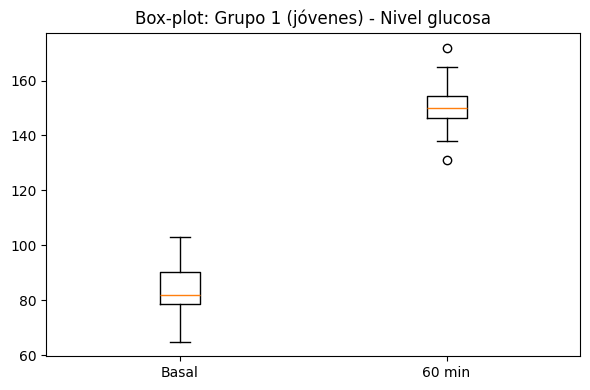

In [24]:
# Boxplot conjunto
fig, ax = plt.subplots(figsize=(6,4))
ax.boxplot([g1[col_basal].dropna(), g1[col_60].dropna()], tick_labels=['Basal','60 min'])
ax.set_title('Box-plot: Grupo 1 (jóvenes) - Nivel glucosa')
plt.tight_layout()
plt.show()

**Cuartiles y outliers (grupo 1 — jóvenes)**

- Los cuartiles imprimidos arriba indican Q1 (25%), Q2 (mediana, 50%) y Q3 (75%) para cada variable.
- Un valor fuera del rango [Q1 - 1.5·IQR, Q3 + 1.5·IQR] se considera atípico según la regla del boxplot.
- El box-plot generado muestra visualmente la mediana, los cuartiles y cualquier valor atípico detectado.

In [31]:
# Pruebas de normalidad para 'Nivel glucosa 60 min' en ambos grupos
import scipy.stats as ss
col_group = 'Grupo de control'
col_60 = 'Nivel glucosa 60 min'
alpha = 0.05
for g in sorted(df[col_group].unique()):
    series = df.loc[df[col_group] == g, col_60].dropna()
    n = len(series)
    print(f'--- Grupo {g} (n={n}) ---')
    # Shapiro-Wilk
    try:
        s_stat, s_p = ss.shapiro(series)
        print(f'Shapiro-Wilk: stat={s_stat:.4f}, p={s_p:.4f} ->', 'Normal' if s_p>alpha else 'No normal')
    except Exception as e:
        print('Shapiro-Wilk: error', e)
    # D'Agostino K^2
    try:
        k_stat, k_p = ss.normaltest(series)
        print(f"D'Agostino K^2: stat={k_stat:.4f}, p={k_p:.4f} ->", 'Normal' if k_p>alpha else 'No normal')
    except Exception as e:
        print("D'Agostino: error", e)
    try:
        ad = ss.anderson(series, dist='norm', method='interpolate')
    except TypeError:
        ad = ss.anderson(series, dist='norm')

    # If the result contains a p-value (newer SciPy with method), use it
    if hasattr(ad, 'pvalue'):
        pval = ad.pvalue
        print(f'Anderson-Darling: stat={ad.statistic:.4f}, p={pval:.4f} ->', 'Normal' if pval>alpha else 'No normal')
    else:
        # Sin P-valor se usan valores criticos
        print(f'Anderson-Darling: stat={ad.statistic:.4f}')
        try:
            cv5 = ad.critical_values[list(ad.significance_level).index(5.0)]
        except ValueError:
            cv5 = ad.critical_values[-2]
        print(f'Crítico 5% = {cv5:.4f} ')
        print(f'----------Decisión (α=0.05):', 'No rechazar normalidad' if ad.statistic <= cv5 else 'Rechazar normalidad')
    print()

--- Grupo 1 (n=35) ---
Shapiro-Wilk: stat=0.9626, p=0.2734 -> Normal
D'Agostino K^2: stat=3.6141, p=0.1641 -> Normal
Anderson-Darling: stat=0.6437, p=0.0887 -> Normal

--- Grupo 2 (n=30) ---
Shapiro-Wilk: stat=0.9776, p=0.7592 -> Normal
D'Agostino K^2: stat=0.5379, p=0.7642 -> Normal
Anderson-Darling: stat=0.2678, p=0.1500 -> Normal



**Interpretación (nivel de significación α = 0.05)**

- Se muestran los resultados de Shapiro-Wilk, D'Agostino (K^2) y Anderson-Darling para `Nivel glucosa 60 min` en cada grupo de control.
- Regla: si el p-valor < 0.05 (Shapiro o D'Agostino) rechazamos normalidad. En Anderson-Darling comparamos la estadística con el valor crítico al 5%.
- Interpreta los resultados numéricos:
  - Ambos grupos pueden considerarse aproximadamente normales (α=0.05), por lo que el uso de pruebas paramétricas (p. ej. t-test para medias) es razonable.